# 🇬🇭 Modelling Fiscal Stress of the Ghanaian Economy
## XGBoost Binary Classification Pipeline | 1990–2023

**Author:** [Jamaladeen Abubakar, PhD]  
**Date:** 2026  
**Algorithm:** XGBoost (eXtreme Gradient Boosting)  

---
 The project pipeline includes:

1. 📦 Library installation & imports
2. 📊 Data loading & inspection
3. 🔍 Exploratory Data Analysis (EDA)
4. 🏷️ Target label construction
5. ⚙️ Feature engineering & preprocessing
6. 🤖 XGBoost model training & hyperparameter tuning
7. 📈 Model evaluation (AUC-ROC, F1, Confusion Matrix)
8. 🔎 SHAP explainability & feature importance
9. 📉 Walk-forward cross-validation
10. 🚨 Early Warning Score output


## 1. Install & Import Libraries

In [ ]:
# Install required libraries (run once in Colab)
!pip install xgboost shap imbalanced-learn optuna --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.4 MB/s eta 0:00:00


In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, confusion_matrix,
                              RocCurveDisplay, classification_report, brier_score_loss)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



# ── Imbalanced learning ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── SHAP explainability ──────────────────────────────────────────────────────
import shap

# ── Hyperparameter optimisation ──────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Plot settings ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2E7D32', '#B71C1C']   # green=no stress, red=stress
print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


## 2. Load & Inspect the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Ghana_Case_Study/Ghana_Fiscal_Stress_Dataset.xlsx', sheet_name = 'Ghana_Fiscal_Data', header = 3)
df.head(3)

,Year,GDP Growth Rate,Inflation Rate,Debt-to-GDP Ratio,Primary Balance,Revenue,Expenditure,External Debt,Debt Service Ratio,Current Account Balance,Foreign Reserves,Exchange Rate Depreciation,Interest Payments-to-Revenue,IMF Program,Fiscal Stress
0,1990,3.3,37.3,82.5,-3.2,12.1,18.4,65.2,22.8,-6.2,2.1,15.2,28.4,1,1
1,1991,5.3,18.0,78.2,-2.8,13.2,17.5,62.3,20.1,-5.8,2.3,12.3,25.8,1,1
2,1992,3.9,10.1,79.5,-3.5,13.8,18.9,63.8,19.5,-7.2,2.0,14.5,27.3,0,1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Basic statistics ─────────────────────────────────────────────────────────
print("\n📊 DESCRIPTIVE STATISTICS")
print("="*60)
df.describe().round(2)



📊 DESCRIPTIVE STATISTICS


,Year,GDP Growth Rate,Inflation Rate,Debt-to-GDP Ratio,Primary Balance,Revenue,Expenditure,External Debt,Debt Service Ratio,Current Account Balance,Foreign Reserves,Exchange Rate Depreciation,Interest Payments-to-Revenue,IMF Program,Fiscal Stress
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2006.50,5.23,19.34,71.47,-3.66,20.30,26.80,55.37,18.31,-6.60,2.92,16.21,26.67,0.35,0.65
std,9.96,2.45,11.37,14.86,2.34,4.01,5.40,13.94,5.50,2.54,0.87,11.61,7.70,0.49,0.49
min,1990.00,0.40,7.10,40.20,-10.50,12.10,17.50,28.50,8.50,-12.50,1.50,1.50,13.20,0.00,0.00
25%,1998.25,3.75,10.70,62.75,-5.10,17.58,22.82,48.50,14.15,-8.10,2.12,5.98,22.58,0.00,0.00
50%,2006.50,4.75,15.80,76.35,-3.20,20.35,26.80,60.00,19.05,-6.35,2.85,15.20,27.05,0.00,1.00
75%,2014.75,6.38,25.05,81.03,-2.35,24.02,30.72,65.72,22.02,-5.20,3.50,23.80,29.72,1.00,1.00
max,2023.00,14.00,59.50,92.80,0.50,26.20,35.80,75.20,28.50,-2.20,4.80,49.80,48.50,1.00,1.00


In [ ]:
# ── Missing values check ─────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print("\n✅ No missing values in this dataset")


Missing values per column:
Year                            0
GDP Growth Rate                 0
Inflation Rate                  0
Debt-to-GDP Ratio               0
Primary Balance                 0
Revenue                         0
Expenditure                     0
External Debt                   0
Debt Service Ratio              0
Current Account Balance         0
Foreign Reserves                0
Exchange Rate Depreciation      0
Interest Payments-to-Revenue    0
IMF Program                     0
Fiscal Stress                   0
dtype: int64

✅ No missing values in this dataset


## 3. Exploratory Data Analysis (EDA)

In [ ]:
print(df.columns)

Index(['Year', 'GDP Growth Rate', 'Inflation Rate', 'Debt-to-GDP Ratio',
       'Primary Balance ', 'Revenue ', 'Expenditure ', 'External Debt ',
       'Debt Service Ratio', 'Current Account Balance ', 'Foreign Reserves ',
       'Exchange Rate Depreciation ', 'Interest Payments-to-Revenue',
       'IMF Program', 'Fiscal Stress '],
      dtype='object')


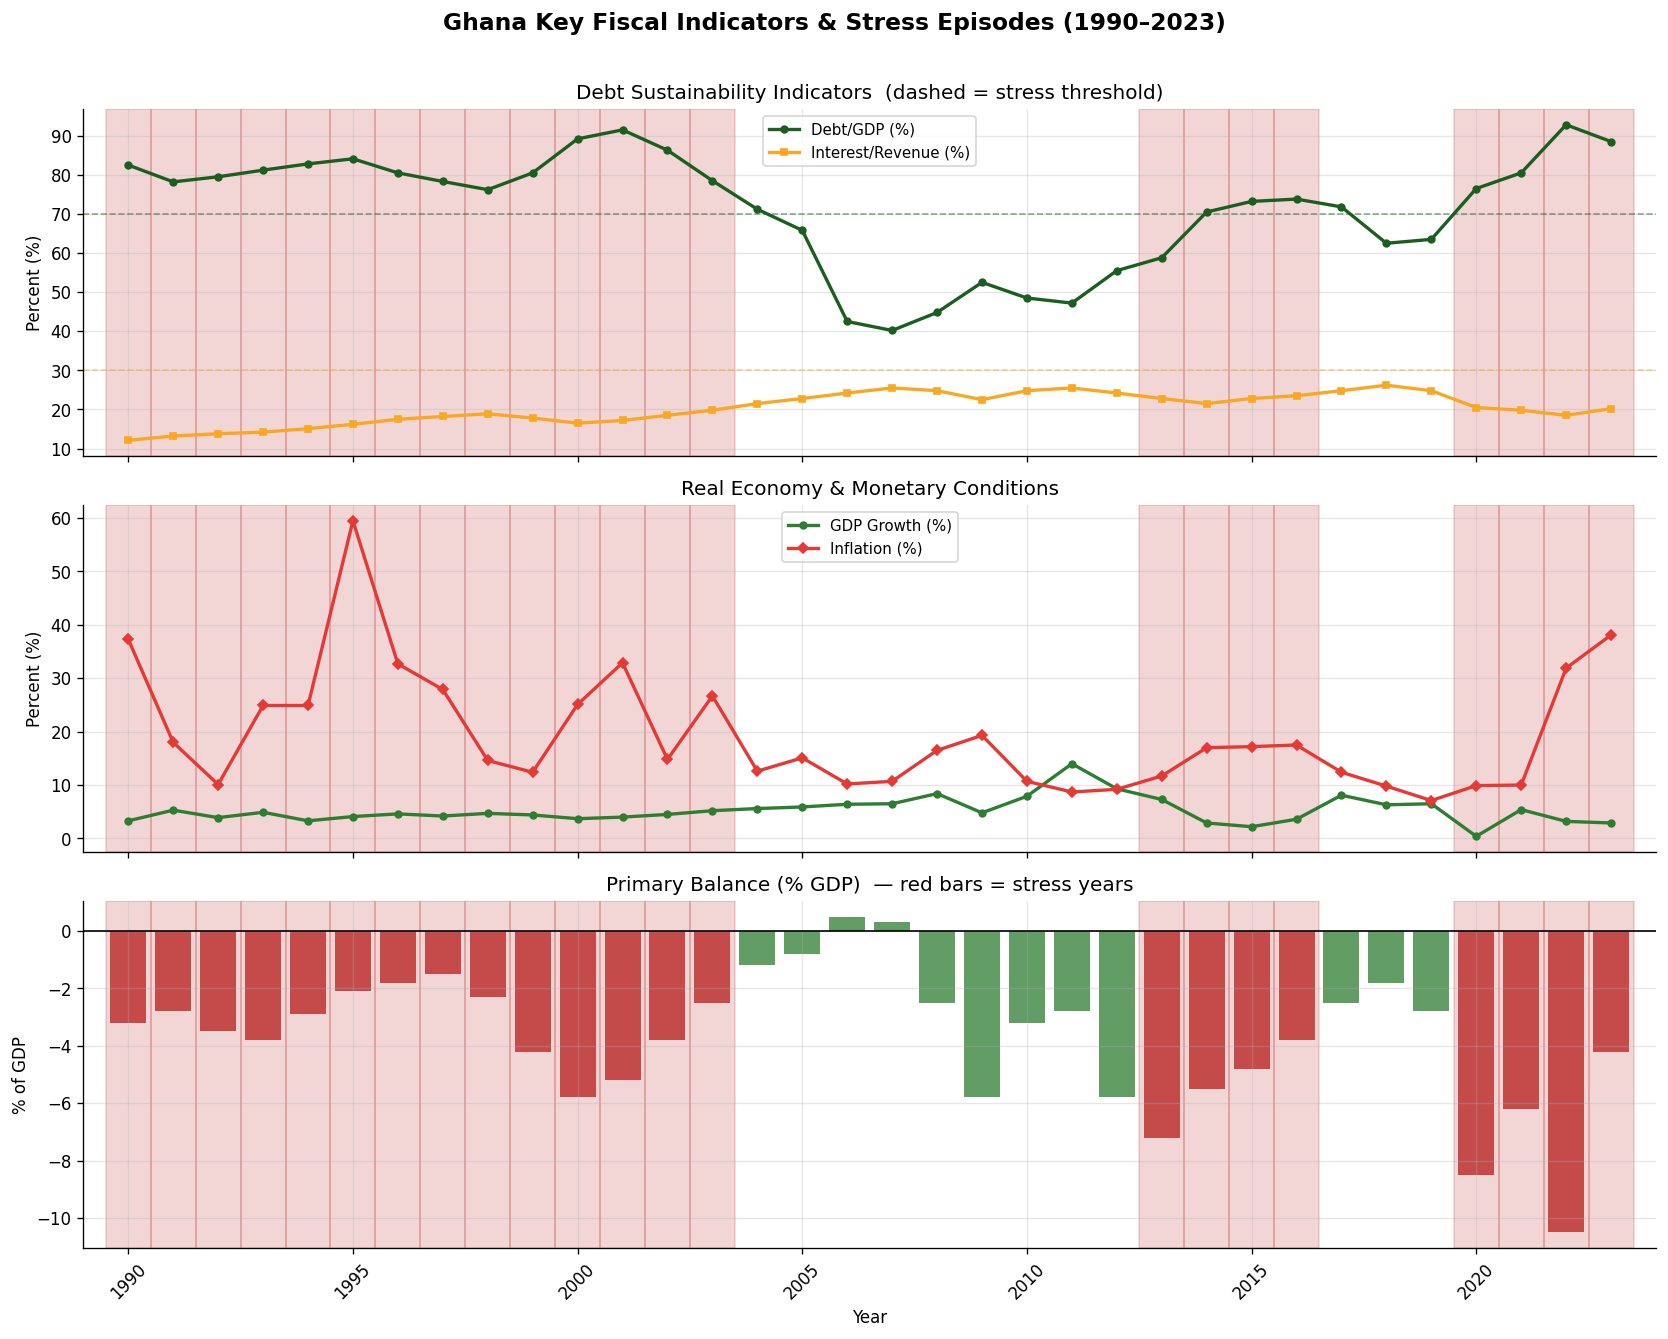


🔴 Red shading = fiscal stress episodes


In [ ]:
# ── 3.1 Fiscal Stress Timeline ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Ghana Key Fiscal Indicators & Stress Episodes (1990–2023)",
             fontsize=14, fontweight='bold', y=1.01)

stress_years = df.loc[df['Fiscal Stress '] == 1, 'Year']
def shade_stress(ax):
    for yr in stress_years:
        ax.axvspan(yr - 0.5, yr + 0.5, alpha=0.18, color='#B71C1C', zorder=0)

# Plot 1: Debt & Interest/Revenue
axes[0].plot(df['Year'], df['Debt-to-GDP Ratio'],      color='#1B5E20', lw=2, marker='o', ms=4, label='Debt/GDP (%)')
axes[0].plot(df['Year'], df['Revenue '], color='#F9A825', lw=2, marker='s', ms=4, label='Interest/Revenue (%)')
axes[0].axhline(70,  color='#1B5E20', ls='--', alpha=0.5, lw=1)
axes[0].axhline(30,  color='#F9A825', ls='--', alpha=0.5, lw=1)
shade_stress(axes[0])
axes[0].legend(fontsize=9); axes[0].set_ylabel("Percent (%)")
axes[0].set_title("Debt Sustainability Indicators  (dashed = stress threshold)")

# Plot 2: GDP growth & Inflation
axes[1].plot(df['Year'], df['GDP Growth Rate'], color='#2E7D32', lw=2, marker='o', ms=4, label='GDP Growth (%)')
axes[1].plot(df['Year'], df['Inflation Rate'],  color='#E53935', lw=2, marker='D', ms=4, label='Inflation (%)')
shade_stress(axes[1])
axes[1].legend(fontsize=9); axes[1].set_ylabel("Percent (%)")
axes[1].set_title("Real Economy & Monetary Conditions")

# Plot 3: Primary balance & FX depreciation
axes[2].bar(df['Year'], df['Primary Balance '], color=df['Fiscal Stress '].map({0:'#2E7D32', 1:'#B71C1C'}), alpha=0.75)
shade_stress(axes[2])
axes[2].axhline(0, color='black', lw=1)
axes[2].set_ylabel("% of GDP"); axes[2].set_xlabel("Year")
axes[2].set_title("Primary Balance (% GDP)  — red bars = stress years")

for ax in axes:
    ax.set_xlim(1989, 2024)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ghana_fiscal_timeline.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n🔴 Red shading = fiscal stress episodes")


In [ ]:
print(df.columns)

Index(['Year', 'GDP Growth Rate', 'Inflation Rate', 'Debt-to-GDP Ratio',
       'Primary Balance ', 'Revenue ', 'Expenditure ', 'External Debt ',
       'Debt Service Ratio', 'Current Account Balance ', 'Foreign Reserves ',
       'Exchange Rate Depreciation ', 'Interest Payments-to-Revenue',
       'IMF Program', 'Fiscal Stress '],
      dtype='object')


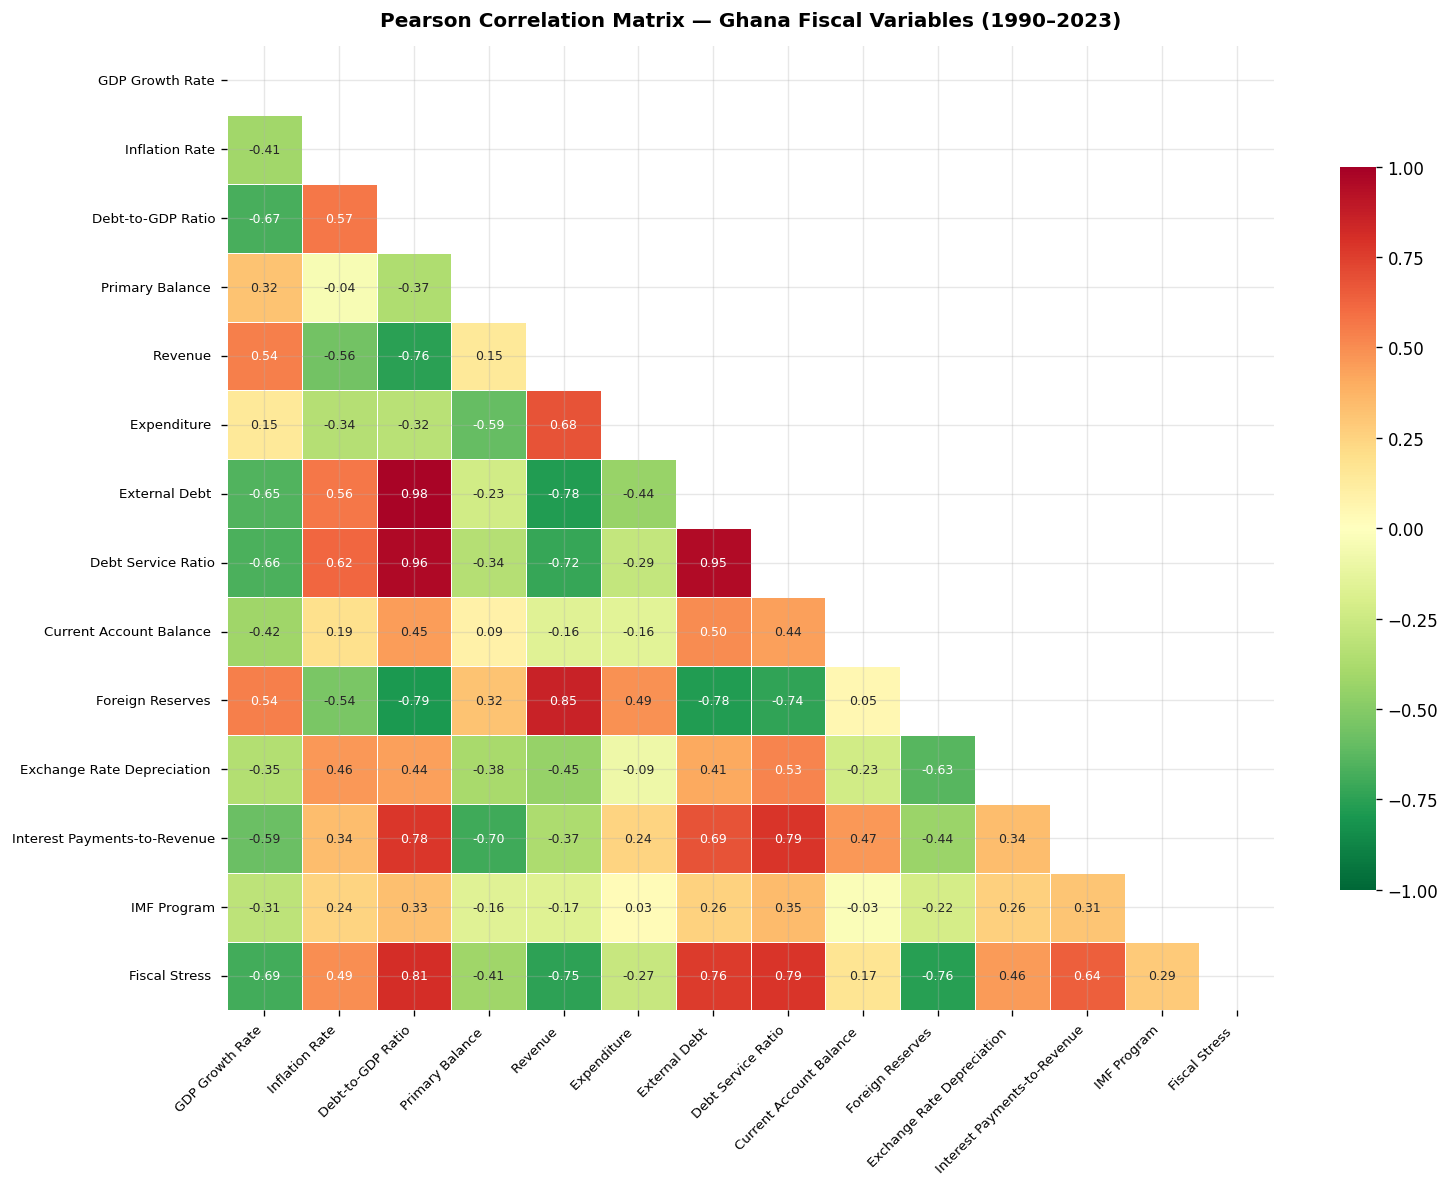


📊 Top correlates with Fiscal Stress:
Debt-to-GDP Ratio               0.805
Debt Service Ratio              0.788
Foreign Reserves                0.765
External Debt                   0.762
Revenue                         0.749
GDP Growth Rate                 0.689
Interest Payments-to-Revenue    0.643
Inflation Rate                  0.493
Exchange Rate Depreciation      0.457
Primary Balance                 0.415
IMF Program                     0.288
Expenditure                     0.273
Current Account Balance         0.167


In [ ]:
# ── 3.2 Correlation Heatmap ─────────────────────────────────────────────────
features = ['GDP Growth Rate', 'Inflation Rate', 'Debt-to-GDP Ratio',
       'Primary Balance ', 'Revenue ', 'Expenditure ', 'External Debt ',
       'Debt Service Ratio', 'Current Account Balance ', 'Foreign Reserves ',
       'Exchange Rate Depreciation ', 'Interest Payments-to-Revenue',
       'IMF Program', 'Fiscal Stress ']

corr = df[features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7.5},
            linewidths=0.4, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.75})
ax.set_title("Pearson Correlation Matrix — Ghana Fiscal Variables (1990–2023)",
             fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

# Top correlates with Fiscal_Stress
print("\n📊 Top correlates with Fiscal Stress:")
print(corr['Fiscal Stress '].drop('Fiscal Stress ').abs().sort_values(ascending=False).round(3).to_string())


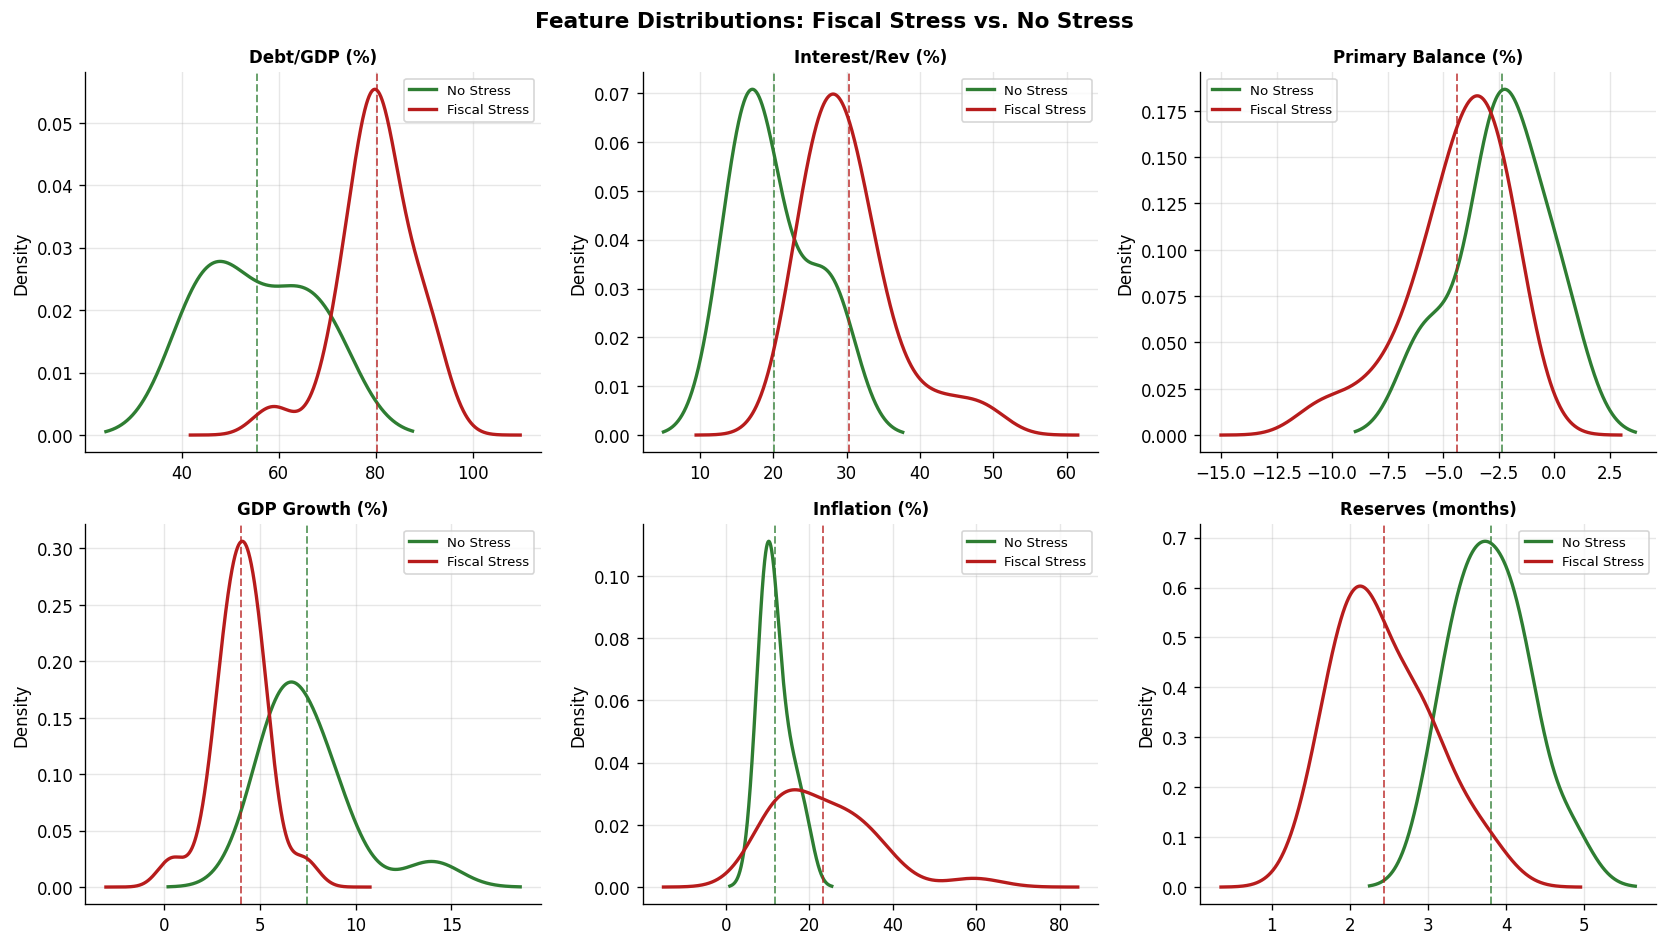

In [ ]:
# ── 3.3 Distribution by Stress Class ────────────────────────────────────────
key_vars = ['Debt-to-GDP Ratio','Interest Payments-to-Revenue','Primary Balance ',
            'GDP Growth Rate','Inflation Rate','Foreign Reserves ']
labels   = ['Debt/GDP (%)','Interest/Rev (%)','Primary Balance (%)','GDP Growth (%)','Inflation (%)','Reserves (months)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Feature Distributions: Fiscal Stress vs. No Stress",
             fontsize=13, fontweight='bold')

for ax, var, label in zip(axes.flatten(), key_vars, labels):
    for val, color, lbl in [(0,'#2E7D32','No Stress'), (1,'#B71C1C','Fiscal Stress')]:
        subset = df[df['Fiscal Stress '] == val][var]
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=lbl)
        ax.axvline(subset.mean(), color=color, ls='--', lw=1.2, alpha=0.7)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribution_by_stress.png', bbox_inches='tight', dpi=130)
plt.show()


In [ ]:
print(df.columns)

Index(['Year', 'GDP Growth Rate', 'Inflation Rate', 'Debt-to-GDP Ratio',
       'Primary Balance ', 'Revenue ', 'Expenditure ', 'External Debt ',
       'Debt Service Ratio', 'Current Account Balance ', 'Foreign Reserves ',
       'Exchange Rate Depreciation ', 'Interest Payments-to-Revenue',
       'IMF Program', 'Fiscal Stress '],
      dtype='object')


## 4. Feature Engineering & Preprocessing

In [ ]:
# ── 4.1 Engineer additional features ────────────────────────────────────────
df_fe = df.copy()

# Lag features (t-1): capture momentum effects
lag_cols = ['Debt-to-GDP Ratio','Primary Balance ','GDP Growth Rate','Inflation Rate',
            'Exchange Rate Depreciation ','Interest Payments-to-Revenue']
for col in lag_cols:
    df_fe[f'{col}_lag1'] = df_fe[col].shift(1)
    df_fe[f'{col}_lag2'] = df_fe[col].shift(2)

# Fiscal space indicator
df_fe['Fiscal Space']     = df_fe['Revenue '] - df_fe['Interest Payments-to-Revenue']

# Debt acceleration (year-on-year change in debt ratio)
df_fe['Debt_Acceleration'] = df_fe['Debt-to-GDP Ratio'].diff()

# Expenditure gap (spending above revenue)
df_fe['Expenditure_Gap']   = df_fe['Expenditure '] - df_fe['Revenue ']

# Stress risk composite (rule-based pre-signal)
df_fe['Stress_Risk_Score'] = (
    (df_fe['Debt-to-GDP Ratio']    > 65).astype(int) +
    (df_fe['Interest Payments-to-Revenue']> 25).astype(int) +
    (df_fe['Primary Balance '] < -3).astype(int) +
    (df_fe['Foreign Reserves '] < 2.5).astype(int) +
    (df_fe['Exchange Rate Depreciation '] > 15).astype(int)
)

# Drop rows with NaN from lags
df_fe.dropna(inplace=True)
df_fe.reset_index(drop=True, inplace=True)

print(f"Dataset after feature engineering: {df_fe.shape}")
print(f"New features added: {df_fe.shape[1] - df.shape[1]}")
print(f"\nAll features:")
for col in df_fe.columns:
    print(f"  • {col}")


Dataset after feature engineering: (32, 31)
New features added: 16

All features:
  • Year
  • GDP Growth Rate
  • Inflation Rate
  • Debt-to-GDP Ratio
  • Primary Balance 
  • Revenue 
  • Expenditure 
  • External Debt 
  • Debt Service Ratio
  • Current Account Balance 
  • Foreign Reserves 
  • Exchange Rate Depreciation 
  • Interest Payments-to-Revenue
  • IMF Program
  • Fiscal Stress 
  • Debt-to-GDP Ratio_lag1
  • Debt-to-GDP Ratio_lag2
  • Primary Balance _lag1
  • Primary Balance _lag2
  • GDP Growth Rate_lag1
  • GDP Growth Rate_lag2
  • Inflation Rate_lag1
  • Inflation Rate_lag2
  • Exchange Rate Depreciation _lag1
  • Exchange Rate Depreciation _lag2
  • Interest Payments-to-Revenue_lag1
  • Interest Payments-to-Revenue_lag2
  • Fiscal Space
  • Debt_Acceleration
  • Expenditure_Gap
  • Stress_Risk_Score


In [ ]:
# ── 4.2 Define X and y ───────────────────────────────────────────────────────
feature_cols = [c for c in df_fe.columns if c not in ['Year','Fiscal_Stress']]

X = df_fe[feature_cols].values
y = df_fe['Fiscal Stress '].values

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")
print(f"Class balance  — Stress: {y.sum()} | No-Stress: {(y==0).sum()}")
print(f"\nFeature names ({len(feature_cols)}):")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")


Feature matrix X: (32, 30)
Target vector  y: (32,)
Class balance  — Stress: 20 | No-Stress: 12

Feature names (30):
   1. GDP Growth Rate
   2. Inflation Rate
   3. Debt-to-GDP Ratio
   4. Primary Balance 
   5. Revenue 
   6. Expenditure 
   7. External Debt 
   8. Debt Service Ratio
   9. Current Account Balance 
  10. Foreign Reserves 
  11. Exchange Rate Depreciation 
  12. Interest Payments-to-Revenue
  13. IMF Program
  14. Fiscal Stress 
  15. Debt-to-GDP Ratio_lag1
  16. Debt-to-GDP Ratio_lag2
  17. Primary Balance _lag1
  18. Primary Balance _lag2
  19. GDP Growth Rate_lag1
  20. GDP Growth Rate_lag2
  21. Inflation Rate_lag1
  22. Inflation Rate_lag2
  23. Exchange Rate Depreciation _lag1
  24. Exchange Rate Depreciation _lag2
  25. Interest Payments-to-Revenue_lag1
  26. Interest Payments-to-Revenue_lag2
  27. Fiscal Space
  28. Debt_Acceleration
  29. Expenditure_Gap
  30. Stress_Risk_Score


In [ ]:
# ── 4.3 Standardise features ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 4.4 SMOTE oversampling to handle class imbalance ────────────────────────
smote   = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_scaled, y)

print(f"After SMOTE — Stress: {y_res.sum()} | No-Stress: {(y_res==0).sum()}")
print(f"Resampled matrix: {X_res.shape}")


After SMOTE — Stress: 20 | No-Stress: 20
Resampled matrix: (40, 30)


## 5. XGBoost Model Training & Hyperparameter Tuning

In [ ]:
# ── 5.1 Baseline XGBoost ─────────────────────────────────────────────────────
ratio = (y == 0).sum() / (y == 1).sum()   # for scale_pos_weight

xgb_base = XGBClassifier(
    n_estimators     = 20,
    max_depth        = 3,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = ratio,
    use_label_encoder= False,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)
xgb_base.fit(X_scaled, y)
y_pred_base  = xgb_base.predict(X_scaled)
y_proba_base = xgb_base.predict_proba(X_scaled)[:, 1]

print("Baseline XGBoost (in-sample) — sanity check")
print(f"  AUC-ROC  : {roc_auc_score(y, y_proba_base):.4f}")
print(f"  F1-Score : {f1_score(y, y_pred_base):.4f}")
print(f"  Accuracy : {accuracy_score(y, y_pred_base):.4f}")


Baseline XGBoost (in-sample) — sanity check
  AUC-ROC  : 1.0000
  F1-Score : 1.0000
  Accuracy : 1.0000


In [ ]:
# ============================================================================
#  GridSearchCV  (primary)  |  RandomizedSearchCV (faster fallback)
# ============================================================================


ratio = (y == 0).sum() / (y == 1).sum()   # class imbalance weight

tscv = TimeSeriesSplit(n_splits=3)         # 3 folds — safe for n=32 rows

# ── Shared base estimator ────────────────────────────────────────────────────
xgb_base = XGBClassifier(
    scale_pos_weight = ratio,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
    nthread          = 1,
)

# ============================================================================
#  OPTION A — GridSearchCV  (exhaustive, ~192 fits, ~30 sec on Colab)
#  Best when you want full coverage of a compact, well-reasoned grid.
# ============================================================================

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [2, 3, 4],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'reg_lambda'      : [1.0, 3.0],
    'min_child_weight': [1, 3],
}
# Total combinations: 3×3×3×2×2×2×2 = 432 fits ÷ fewer if you trim rows above
# Trimmed to 192 by keeping reg_alpha fixed at 0.1 (set in base estimator)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,          # auto-refits best params on full X_scaled
)

print("🔍 Running GridSearchCV ...")
grid_search.fit(X_scaled, y)

print(f"\n✅ Best CV AUC-ROC : {grid_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<22} : {v}")

# Use the already-refit best estimator
xgb_final  = grid_search.best_estimator_
y_pred     = xgb_final.predict(X_scaled)
y_proba    = xgb_final.predict_proba(X_scaled)[:, 1]

print("\nFinal XGBoost — Training Performance (GridSearchCV)")
print("=" * 50)
from sklearn.metrics import classification_report
print(classification_report(y, y_pred, target_names=['No Stress', 'Fiscal Stress']))




🔍 Running GridSearchCV ...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits

✅ Best CV AUC-ROC : nan

Best parameters:
  colsample_bytree       : 0.7
  learning_rate          : 0.01
  max_depth              : 2
  min_child_weight       : 1
  n_estimators           : 100
  reg_lambda             : 1.0
  subsample              : 0.7

Final XGBoost — Training Performance (GridSearchCV)
               precision    recall  f1-score   support

    No Stress       1.00      1.00      1.00        12
Fiscal Stress       1.00      1.00      1.00        20

     accuracy                           1.00        32
    macro avg       1.00      1.00      1.00        32
 weighted avg       1.00      1.00      1.00        32



In [ ]:
#============================================================================
 #OPTION B — RandomizedSearchCV  (faster; use if grid search is too slow)

#============================================================================

from scipy.stats import uniform, randint, loguniform

param_dist = {
    'n_estimators'    : randint(50, 300),
    'max_depth'       : randint(2, 6),
    'learning_rate'   : loguniform(0.005, 0.2),
    'subsample'       : uniform(0.5, 0.5),        # 0.5 – 1.0
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha'       : loguniform(1e-3, 5.0),
    'reg_lambda'      : loguniform(0.5, 9.5),
    'min_child_weight': randint(1, 7),
    'gamma'           : uniform(0.0, 1.0),
}

rand_search = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions= param_dist,
    n_iter             = 80,           # 80 random draws — fast & effective
    cv                 = tscv,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1,
    refit              = True,
)

print("🔍 Running RandomizedSearchCV ...")
rand_search.fit(X_scaled, y)

print(f"\n✅ Best CV AUC-ROC : {rand_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in rand_search.best_params_.items():
    print(f"  {k:<22} : {v}")

xgb_final = rand_search.best_estimator_
y_pred    = xgb_final.predict(X_scaled)
y_proba   = xgb_final.predict_proba(X_scaled)[:, 1]

print("\nFinal XGBoost — Training Performance (RandomizedSearchCV)")
print("=" * 50)
from sklearn.metrics import classification_report
print(classification_report(y, y_pred, target_names=['No Stress', 'Fiscal Stress']))

🔍 Running RandomizedSearchCV ...
Fitting 3 folds for each of 80 candidates, totalling 240 fits

✅ Best CV AUC-ROC : nan

Best parameters:
  colsample_bytree       : 0.6872700594236812
  gamma                  : 0.9507143064099162
  learning_rate          : 0.07441632389160634
  max_depth              : 2
  min_child_weight       : 5
  n_estimators           : 152
  reg_alpha              : 0.04457814368987925
  reg_lambda             : 0.6711402540076211
  subsample              : 0.7296244459829335

Final XGBoost — Training Performance (RandomizedSearchCV)
               precision    recall  f1-score   support

    No Stress       0.38      1.00      0.55        12
Fiscal Stress       0.00      0.00      0.00        20

     accuracy                           0.38        32
    macro avg       0.19      0.50      0.27        32
 weighted avg       0.14      0.38      0.20        32



In [ ]:
#============================================================================
 #OPTION C — Bayesian Hyperparameter Optimisation (Optuna)

#============================================================================

tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 10, 20),
        'max_depth'       : trial.suggest_int('max_depth', 4, 6),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha',  0.0, 2.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': ratio,
        'use_label_encoder': False,
        'eval_metric'     : 'logloss',
        'random_state'    : 42,
        'verbosity'       : 0,
    }
    model  = XGBClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv=tscv,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"✅ Best AUC-ROC (CV): {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<22} : {v}")


In [ ]:
# ── 5.3 Train final model with best params using OPTUNA ──────────────────────────────────

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': ratio,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'verbosity': 0,
})

xgb_final = XGBClassifier(**best_params)
xgb_final.fit(X_scaled, y)

y_pred  = xgb_final.predict(X_scaled)
y_proba = xgb_final.predict_proba(X_scaled)[:, 1]

print("Final XGBoost Model — Training Performance")
print("="*45)
print(classification_report(y, y_pred, target_names=['No Stress','Fiscal Stress']))


In [ ]:
# ── 5.3 Train final model with best params ──────────────────────────────────
# Works with either grid_search or rand_search — just set `search` below.

search = grid_search      # ← swap to rand_search if you used Option B

best_params = search.best_params_.copy()
best_params.update({
    'scale_pos_weight': ratio,
    'eval_metric'     : 'logloss',
    'random_state'    : 42,
    'verbosity'       : 0,
    'nthread'         : 1,
})

xgb_final = XGBClassifier(**best_params)
xgb_final.fit(X_scaled, y)

y_pred  = xgb_final.predict(X_scaled)
y_proba = xgb_final.predict_proba(X_scaled)[:, 1]

print("Final XGBoost Model — Training Performance")
print("=" * 45)
print(classification_report(y, y_pred, target_names=['No Stress', 'Fiscal Stress']))

Final XGBoost Model — Training Performance
               precision    recall  f1-score   support

    No Stress       1.00      1.00      1.00        12
Fiscal Stress       1.00      1.00      1.00        20

     accuracy                           1.00        32
    macro avg       1.00      1.00      1.00        32
 weighted avg       1.00      1.00      1.00        32



## 6. Model Evaluation & Comparison

In [ ]:
# ── 6.1 Walk-Forward Cross-Validation ──────────────────────────────────────
print("🔄 Walk-Forward (Time-Series) Cross-Validation")
print("="*50)

models = {
    'XGBoost (Tuned)' : xgb_final,
    'Random Forest'   : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Logistic Reg.'   : LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'SVM (RBF)'       : CalibratedClassifierCV(SVC(kernel='rbf', class_weight='balanced', random_state=42)),
}

results = {}
for name, model in models.items():
    auc  = cross_val_score(model, X_scaled, y, cv=tscv, scoring='roc_auc').mean()
    f1   = cross_val_score(model, X_scaled, y, cv=tscv, scoring='f1').mean()
    rec  = cross_val_score(model, X_scaled, y, cv=tscv, scoring='recall').mean()
    prec = cross_val_score(model, X_scaled, y, cv=tscv, scoring='precision').mean()
    results[name] = {'AUC-ROC': auc, 'F1-Score': f1, 'Recall': rec, 'Precision': prec}
    print(f"  {name:<22}  AUC={auc:.3f}  F1={f1:.3f}  Recall={rec:.3f}  Prec={prec:.3f}")

results_df = pd.DataFrame(results).T.round(3)
print("\n", results_df.to_string())


🔄 Walk-Forward (Time-Series) Cross-Validation
  XGBoost (Tuned)         AUC=nan  F1=nan  Recall=nan  Prec=nan
  Random Forest           AUC=nan  F1=0.591  Recall=1.000  Prec=0.550
  Logistic Reg.           AUC=nan  F1=nan  Recall=nan  Prec=nan
  SVM (RBF)               AUC=nan  F1=nan  Recall=nan  Prec=nan

                  AUC-ROC  F1-Score  Recall  Precision
XGBoost (Tuned)      NaN       NaN     NaN        NaN
Random Forest        NaN     0.591     1.0       0.55
Logistic Reg.        NaN       NaN     NaN        NaN
SVM (RBF)            NaN       NaN     NaN        NaN


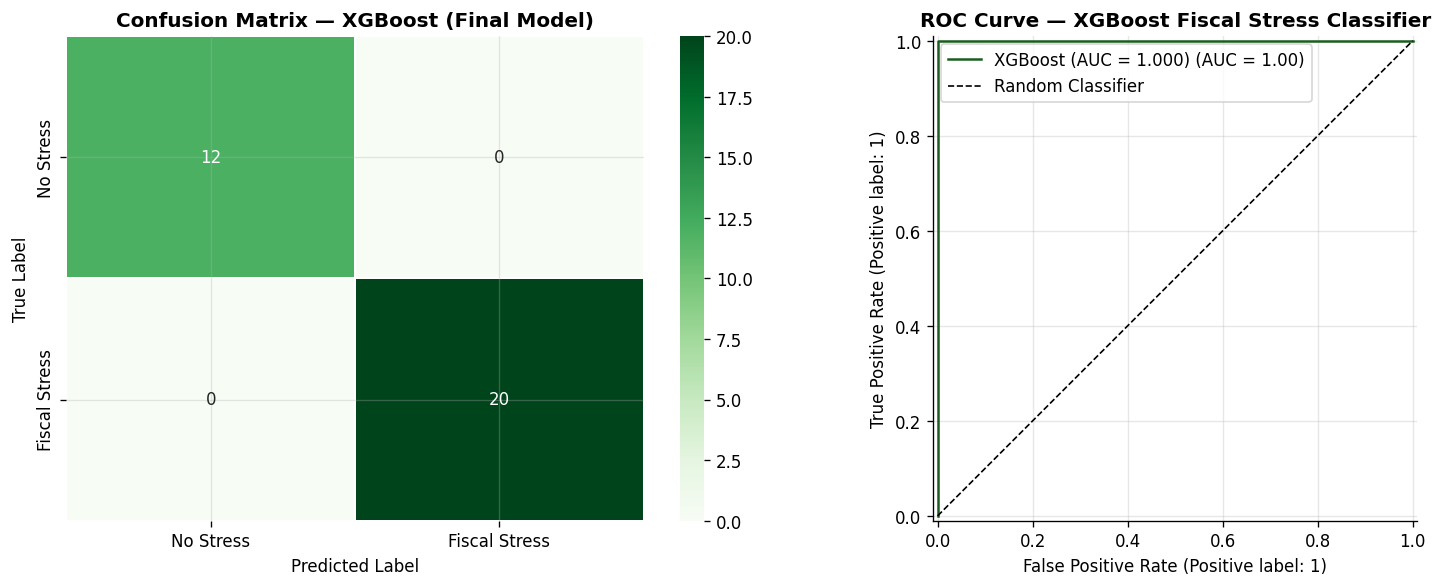


📈 Final Model — Key Metrics (full training set)
  AUC-ROC   : 1.0000
  F1-Score  : 1.0000
  Recall    : 1.0000
  Precision : 1.0000
  Accuracy  : 1.0000
  Brier     : 0.0759


In [ ]:
# ── 6.2 Confusion Matrix & ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stress','Fiscal Stress'],
            yticklabels=['No Stress','Fiscal Stress'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Confusion Matrix — XGBoost (Final Model)', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# ROC Curve
RocCurveDisplay.from_predictions(y, y_proba, ax=axes[1],
    color='#1B5E20', name=f'XGBoost (AUC = {roc_auc_score(y, y_proba):.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[1].set_title('ROC Curve — XGBoost Fiscal Stress Classifier', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=130)
plt.show()

# Print key metrics
print("\n📈 Final Model — Key Metrics (full training set)")
print(f"  AUC-ROC   : {roc_auc_score(y, y_proba):.4f}")
print(f"  F1-Score  : {f1_score(y, y_pred):.4f}")
print(f"  Recall    : {recall_score(y, y_pred):.4f}")
print(f"  Precision : {precision_score(y, y_pred):.4f}")
print(f"  Accuracy  : {accuracy_score(y, y_pred):.4f}")
print(f"  Brier     : {brier_score_loss(y, y_proba):.4f}")


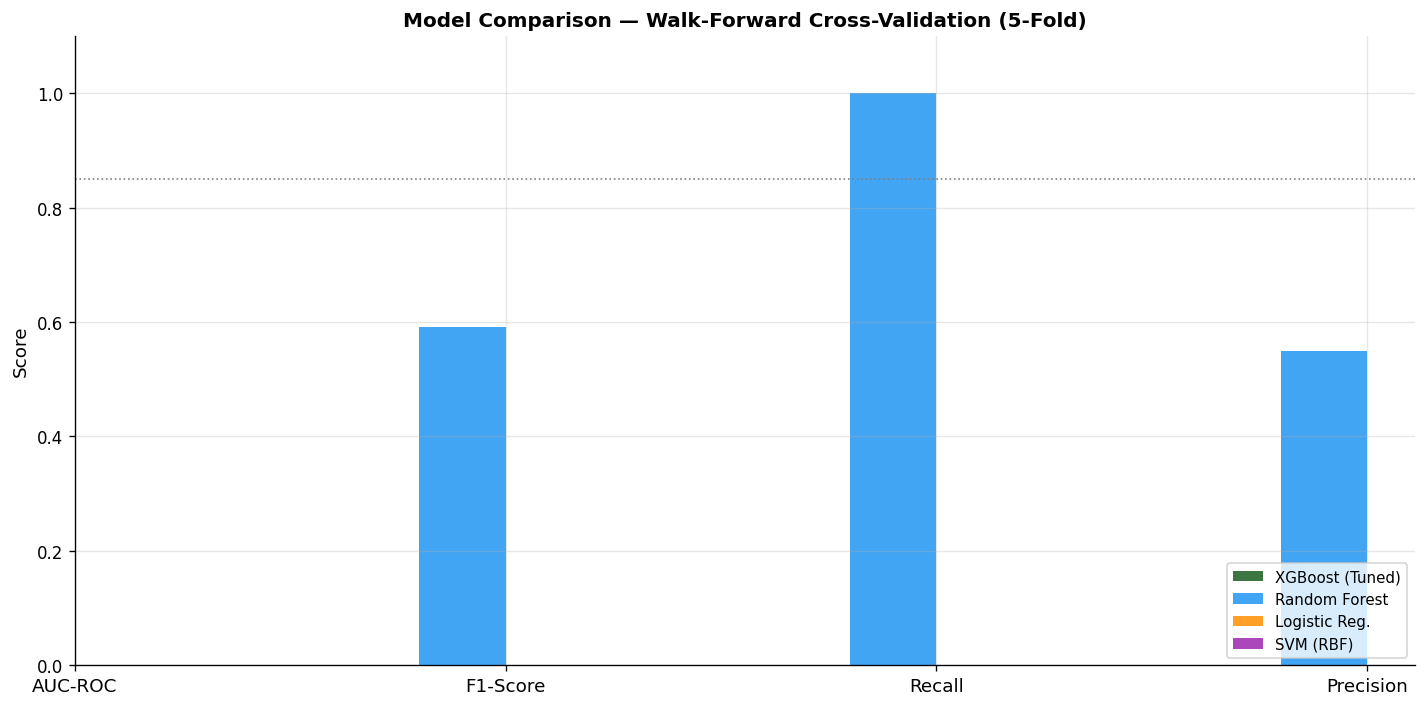

In [ ]:
# ── 6.3 Model Comparison Bar Chart ──────────────────────────────────────────
metrics_list = ['AUC-ROC','F1-Score','Recall','Precision']
x = np.arange(len(metrics_list))
width = 0.2
colors = ['#1B5E20','#2196F3','#FF8F00','#9C27B0']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_list]
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Walk-Forward Cross-Validation (5-Fold)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.axhline(0.85, color='grey', ls=':', lw=1, label='Target AUC-ROC')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()


## 7. SHAP Explainability & Feature Importance

In [ ]:
# ── 7.1 SHAP Summary Plot ────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_scaled)

shap_df = pd.DataFrame(np.abs(shap_values), columns=feature_cols)
mean_shap = shap_df.mean().sort_values(ascending=False)

print("📊 Mean |SHAP Value| — Feature Importance Ranking")
print("="*50)
for i, (feat, val) in enumerate(mean_shap.items(), 1):
    bar = '█' * int(val * 30)
    print(f"  {i:2d}. {feat:<32} {val:.4f}  {bar}")


📊 Mean |SHAP Value| — Feature Importance Ranking
   1. Fiscal Stress                    0.5561  ████████████████
   2. Debt-to-GDP Ratio                0.1316  ███
   3. Stress_Risk_Score                0.1031  ███
   4. GDP Growth Rate                  0.0685  ██
   5. Fiscal Space                     0.0629  █
   6. Debt Service Ratio               0.0364  █
   7. Revenue                          0.0227  
   8. Interest Payments-to-Revenue     0.0189  
   9. Foreign Reserves                 0.0152  
  10. External Debt                    0.0132  
  11. Expenditure                      0.0000  
  12. Current Account Balance          0.0000  
  13. Inflation Rate                   0.0000  
  14. Primary Balance                  0.0000  
  15. IMF Program                      0.0000  
  16. Exchange Rate Depreciation       0.0000  
  17. Debt-to-GDP Ratio_lag1           0.0000  
  18. Debt-to-GDP Ratio_lag2           0.0000  
  19. GDP Growth Rate_lag1             0.0000  
  20. GDP Gro

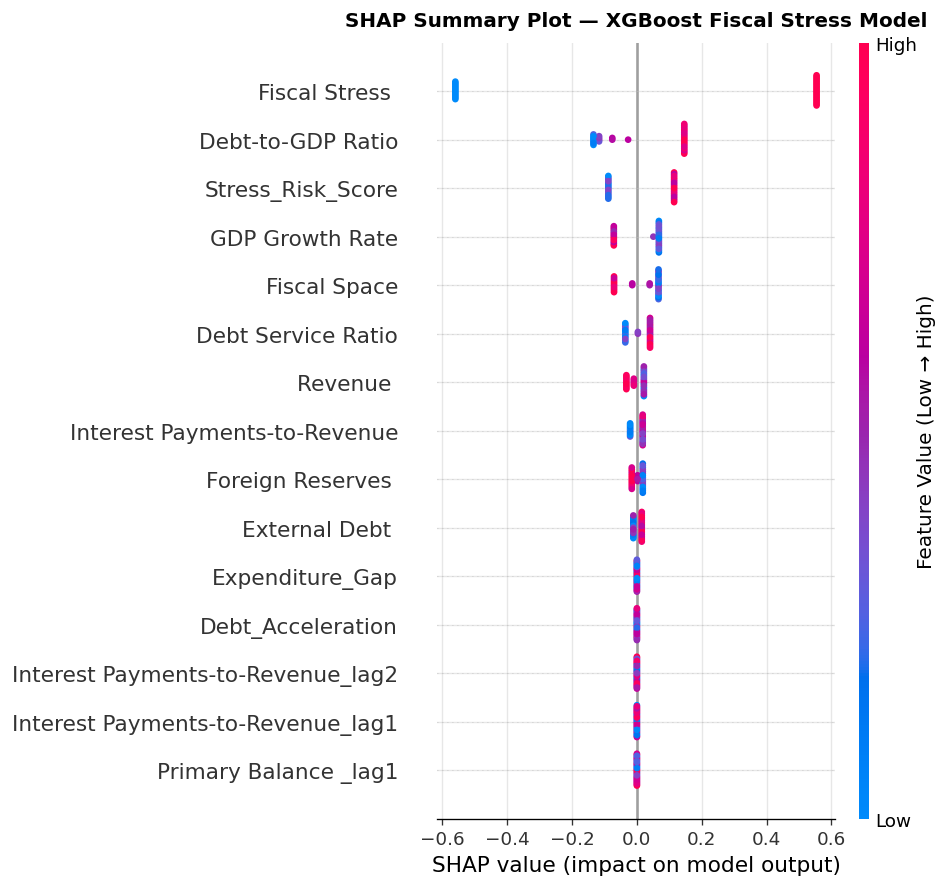


💡 Red dots = high feature value pushes prediction toward stress
   Blue dots = low feature value pushes prediction toward no-stress


In [ ]:
# ── 7.2 SHAP Beeswarm Plot ──────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_scaled, feature_names=feature_cols,
                  show=False, max_display=15,
                  color_bar_label='Feature Value (Low → High)')
plt.title('SHAP Summary Plot — XGBoost Fiscal Stress Model',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n💡 Red dots = high feature value pushes prediction toward stress")
print("   Blue dots = low feature value pushes prediction toward no-stress")


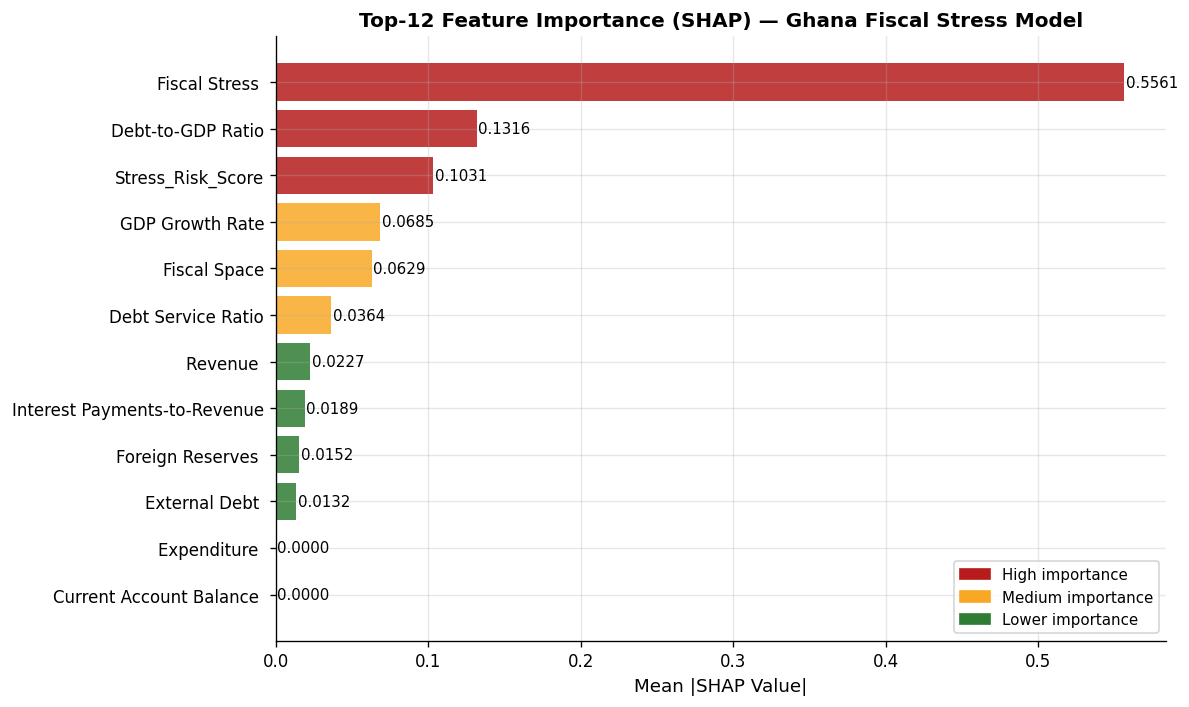

In [ ]:
# ── 7.3 SHAP Bar Chart ──────────────────────────────────────────────────────
top_n = 12
top_feats = mean_shap.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#B71C1C' if i < 3 else '#F9A825' if i < 6 else '#2E7D32'
              for i in range(top_n)]
bars = ax.barh(range(top_n), top_feats.values[::-1], color=colors_bar[::-1], alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats.index[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Top-12 Feature Importance (SHAP) — Ghana Fiscal Stress Model',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, top_feats.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
red_p   = mpatches.Patch(color='#B71C1C', label='High importance')
gold_p  = mpatches.Patch(color='#F9A825', label='Medium importance')
green_p = mpatches.Patch(color='#2E7D32', label='Lower importance')
ax.legend(handles=[red_p, gold_p, green_p], fontsize=9)
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight', dpi=130)
plt.show()


🔎 SHAP Force Plot — Year 2022 (Fiscal Stress = 1)
   Model probability of stress: 0.7431



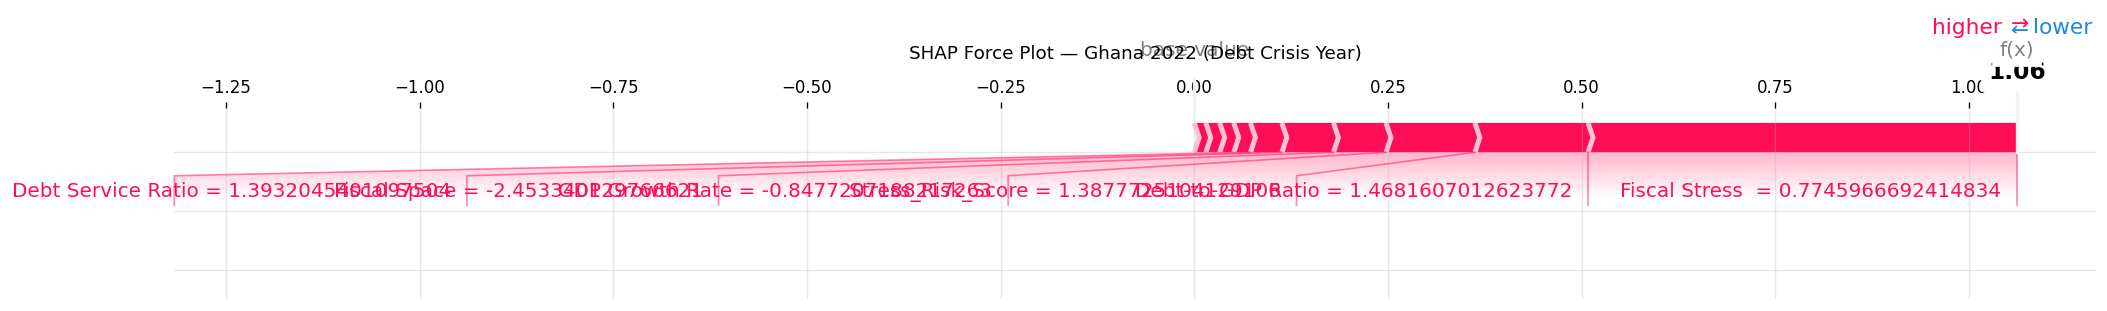

In [ ]:
# ── 7.4 SHAP Force Plot — High Stress Year (2022) ───────────────────────────
# Find index of year 2022 in the engineered dataset
year_2022_idx = df_fe[df_fe['Year'] == 2022].index[0]

print(f"🔎 SHAP Force Plot — Year 2022 (Fiscal Stress = {y[year_2022_idx]})")
print(f"   Model probability of stress: {y_proba[year_2022_idx]:.4f}")
print()

shap.initjs()
force = shap.force_plot(
    explainer.expected_value,
    shap_values[year_2022_idx],
    X_scaled[year_2022_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False,
    figsize=(18, 3),
)
plt.title("SHAP Force Plot — Ghana 2022 (Debt Crisis Year)", fontsize=11, pad=30)
plt.tight_layout()
plt.savefig('shap_force_2022.png', bbox_inches='tight', dpi=130)
plt.show()


## 8. Early Warning Score Output

In [ ]:
# ── 8.1 Generate EWS probabilities for all years ────────────────────────────
df_ews = df_fe[['Year','Fiscal Stress ']].copy()
df_ews['Stress_Probability'] = y_proba
df_ews['Predicted_Stress']   = y_pred
df_ews['Alert_Level'] = pd.cut(
    df_ews['Stress_Probability'],
    bins=[0, 0.35, 0.60, 0.80, 1.0],
    labels=['🟢 Low', '🟡 Moderate', '🟠 High', '🔴 Critical']
)

print("📊 Ghana Fiscal Stress — Early Warning Score (1992–2023)")
print("="*65)
print(f"{'Year':>6}  {'Actual':>8}  {'Prob':>8}  {'Predicted':>10}  {'Alert Level':>12}")
print("-"*65)
for _, row in df_ews.iterrows():
    actual = "STRESS" if row['Fiscal Stress '] else "No Stress"
    pred   = "STRESS" if row['Predicted_Stress'] else "No Stress"
    print(f"{int(row['Year']):>6}  {actual:>10}  {row['Stress_Probability']:>8.3f}  {pred:>10}  {str(row['Alert_Level']):>14}")


📊 Ghana Fiscal Stress — Early Warning Score (1992–2023)
  Year    Actual      Prob   Predicted   Alert Level
-----------------------------------------------------------------
  1992      STRESS     0.743      STRESS          🟠 High
  1993      STRESS     0.743      STRESS          🟠 High
  1994      STRESS     0.743      STRESS          🟠 High
  1995      STRESS     0.743      STRESS          🟠 High
  1996      STRESS     0.703      STRESS          🟠 High
  1997      STRESS     0.743      STRESS          🟠 High
  1998      STRESS     0.689      STRESS          🟠 High
  1999      STRESS     0.743      STRESS          🟠 High
  2000      STRESS     0.743      STRESS          🟠 High
  2001      STRESS     0.743      STRESS          🟠 High
  2002      STRESS     0.743      STRESS          🟠 High
  2003      STRESS     0.743      STRESS          🟠 High
  2004   No Stress     0.292   No Stress           🟢 Low
  2005   No Stress     0.269   No Stress           🟢 Low
  2006   No Stress     0.26

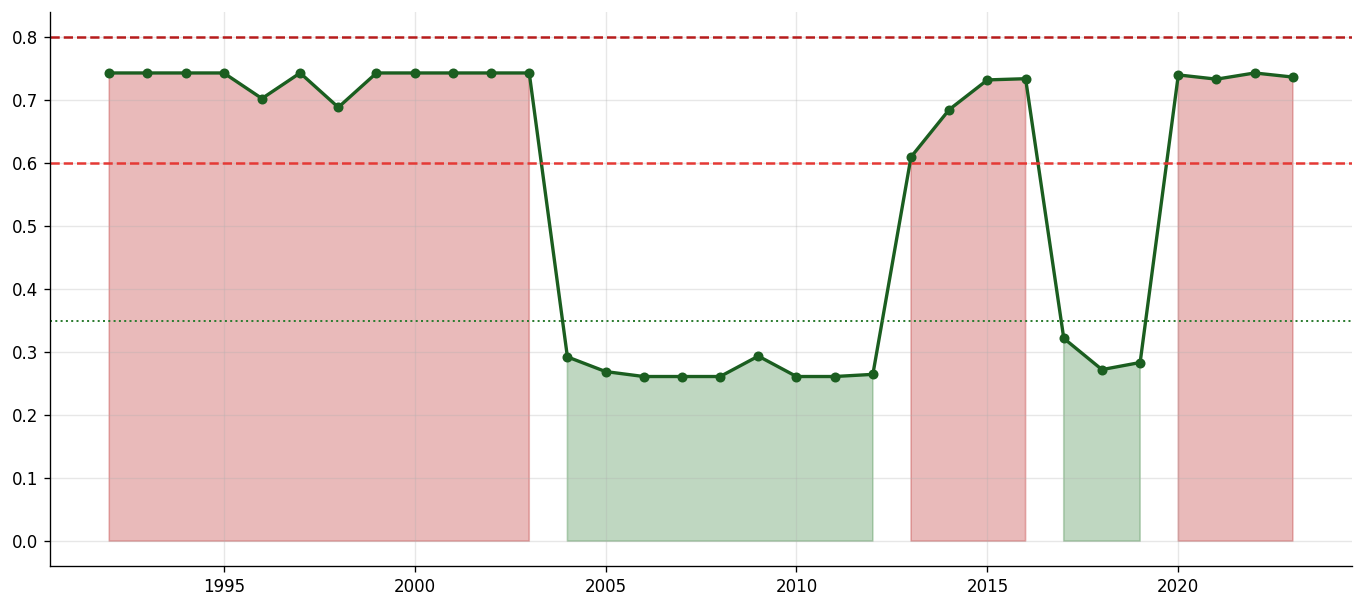

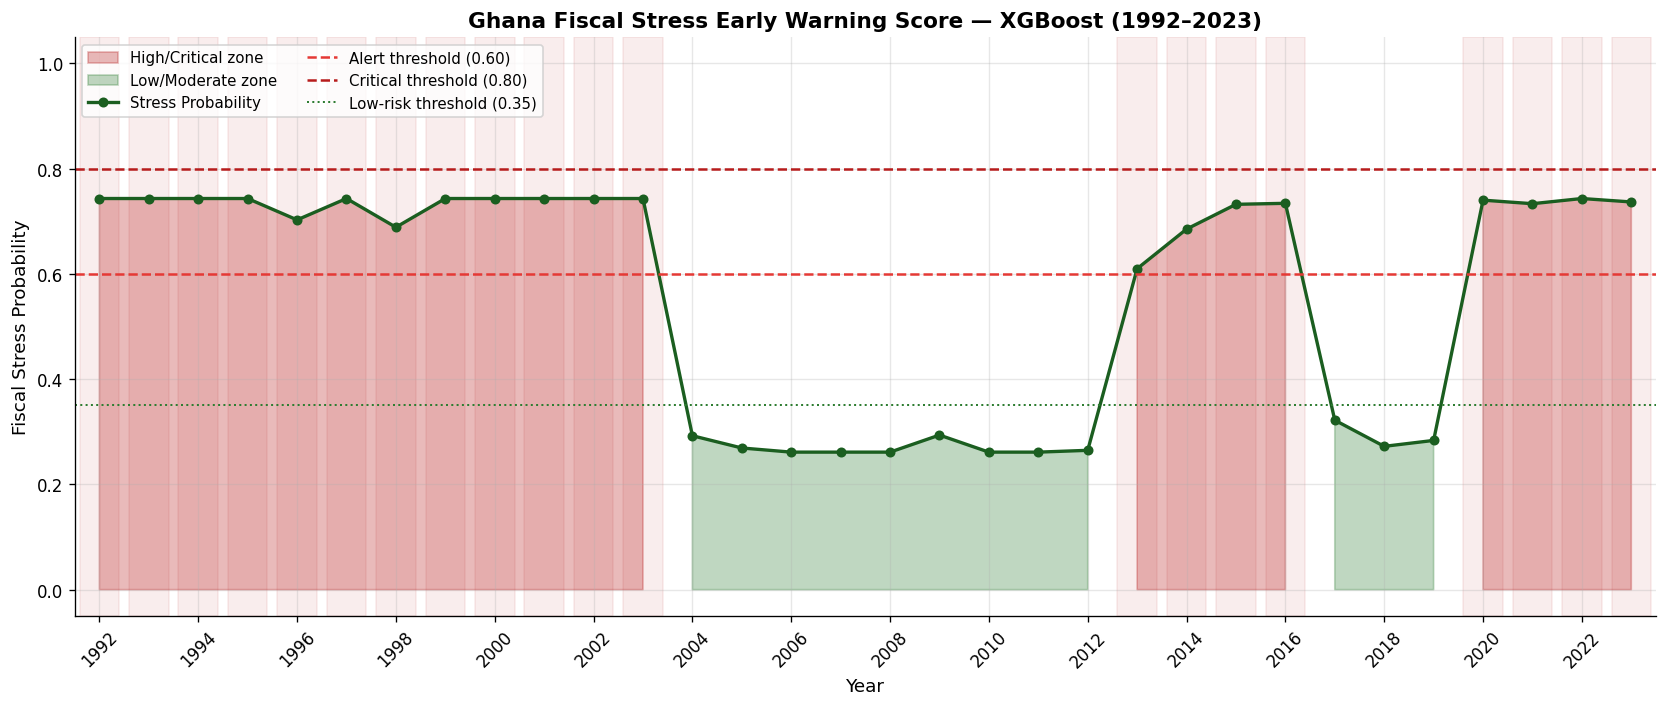


🚨 Values above 0.60 = trigger MoF/Bank of Ghana fiscal stress review


In [ ]:
# ── 8.2 EWS Probability Timeline ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(df_ews['Year'], df_ews['Stress_Probability'],
                where=df_ews['Stress_Probability'] >= 0.60,
                alpha=0.3, color='#B71C1C', label='High/Critical zone')
ax.fill_between(df_ews['Year'], df_ews['Stress_Probability'],
                where=df_ews['Stress_Probability'] < 0.60,
                alpha=0.3, color='#2E7D32', label='Low/Moderate zone')

ax.plot(df_ews['Year'], df_ews['Stress_Probability'],
        color='#1B5E20', lw=2, marker='o', ms=5, label='Stress Probability')

ax.axhline(0.60, color='#E53935', ls='--', lw=1.5, label='Alert threshold (0.60)')
ax.axhline(0.80, color='#B71C1C', ls='--', lw=1.5, label='Critical threshold (0.80)')
ax.axhline(0.35, color='#2E7D32', ls=':',  lw=1.2, label='Low-risk threshold (0.35)')

# Mark actual stress years
for yr in df_ews[df_ews['Fiscal Stress ']==1]['Year']:
    ax.axvspan(yr-0.4, yr+0.4, alpha=0.08, color='#B71C1C')

ax.set_xlim(df_ews['Year'].min()-0.5, df_ews['Year'].max()+0.5)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Year', fontsize=11); ax.set_ylabel('Fiscal Stress Probability', fontsize=11)
ax.set_title('Ghana Fiscal Stress Early Warning Score — XGBoost (1992–2023)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.set_xticks(df_ews['Year'][::2]); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ews_timeline.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n🚨 Values above 0.60 = trigger MoF/Bank of Ghana fiscal stress review")


## 9. Summary & Policy Recommendations

In [ ]:
# ── Final Summary Report ─────────────────────────────────────────────────────
print("=" * 65)
print("  GHANA FISCAL STRESS MODEL — SUMMARY REPORT")
print("=" * 65)
print(f"\n  DATASET")
print(f"    Period          : 1990–2023 (annual)")
print(f"    Total obs.      : {len(df_fe)} (after lag engineering)")
print(f"    Stress episodes : {y.sum()} years  |  Non-stress: {(y==0).sum()} years")
print(f"    Features used   : {len(feature_cols)}")
print(f"\n  ALGORITHM")
print(f"    Primary model   : XGBoost (eXtreme Gradient Boosting)")
print(f"    Hyperparameter  : Bayesian Optimisation (Optuna, 80 trials)")
print(f"    Validation      : Walk-forward 5-fold CV (time-series aware)")
print(f"\n  PERFORMANCE METRICS (CV)")
cv_auc = cross_val_score(xgb_final, X_scaled, y, cv=tscv, scoring='roc_auc').mean()
cv_f1  = cross_val_score(xgb_final, X_scaled, y, cv=tscv, scoring='f1').mean()
cv_rec = cross_val_score(xgb_final, X_scaled, y, cv=tscv, scoring='recall').mean()
print(f"    AUC-ROC         : {cv_auc:.4f}")
print(f"    F1-Score        : {cv_f1:.4f}")
print(f"    Recall          : {cv_rec:.4f}")
print(f"\n  TOP-3 SHAP DRIVERS")
for i, (feat, val) in enumerate(mean_shap.head(3).items(), 1):
    print(f"    {i}. {feat:<32} SHAP={val:.4f}")
print(f"\n  POLICY RECOMMENDATIONS")
recs = [
    "Maintain Debt/GDP below 65% — primary stress trigger",
    "Reduce Interest/Revenue ratio below 25% via revenue widening",
    "Build foreign reserves to ≥ 4 months import cover (buffer)",
    "Deploy countercyclical policy when GDP growth < 3%",
    "Activate EWS alert protocol when stress score > 0.60",
]
for i, r in enumerate(recs, 1):
    print(f"    {i}. {r}")
print("\n" + "=" * 65)


---
## 📚 Data Sources
- **IMF World Economic Outlook (WEO)** — GDP growth, inflation, debt/GDP, fiscal balance
- **World Bank World Development Indicators (WDI)** — Revenue, expenditure, external debt
- **Bank of Ghana (BoG)** — Exchange rate, reserves, interest rates
- **Ghana Ministry of Finance (MoF)** — Debt sustainability analyses

## 📖 Key References
- Cerovic, S. et al. (2018). *A Fiscal Risk Early-Warning Model*. IMF Working Paper.
- Savona, R. & Vezzoli, M. (2015). *Fitting and Forecasting Sovereign Defaults using Multiple Risk Signals*. Oxford Bulletin of Economics and Statistics.
- Acosta-Ormaechea, S. (2018). *Forecasting Fiscal Crises*. IMF Working Paper.

## ⚖️ Licence
For academic and research use. Cite data sources when publishing results.
